In [1]:
import random
from collections import deque
import plotly.graph_objects as go
import pandas as pd

In [2]:
config = {
    'total_meja': 60,
    'mahasiswa_per_meja': 3,
    'random_seed': 42,
    'stage1_workers': 3,
    'stage2_workers': 2,
    'stage3_workers': 2,
    'stage1_min': 15,
    'stage1_max': 30,
    'stage2_min': 10,
    'stage2_max': 25,
    'stage3_min': 15,
    'stage3_max': 30,
    'batch_min': 5,
    'batch_max': 8
}

In [3]:
def simulate_piket(config):
    random.seed(config['random_seed'])
    TOTAL_OMPRENG = config['total_meja'] * config['mahasiswa_per_meja']

    finish_stage1 = [0.0] * TOTAL_OMPRENG
    worker_next_free = [0.0] * config['stage1_workers']

    for i in range(TOTAL_OMPRENG):
        worker_idx = min(range(config['stage1_workers']), key=lambda x: worker_next_free[x])
        start_time = worker_next_free[worker_idx]
        duration = random.uniform(config['stage1_min'], config['stage1_max'])
        finish_time = start_time + duration
        worker_next_free[worker_idx] = finish_time
        finish_stage1[i] = finish_time

    finish_stage2 = [0.0] * TOTAL_OMPRENG
    stage2_workers = [0.0] * config['stage2_workers']
    ompreng_sorted = sorted(range(TOTAL_OMPRENG), key=lambda x: finish_stage1[x])
    buffer = deque(ompreng_sorted)
    batch_sizes = []

    while buffer:
        batch_size = random.randint(config['batch_min'], config['batch_max'])
        batch_size = min(batch_size, len(buffer))
        batch = [buffer.popleft() for _ in range(batch_size)]
        batch_sizes.append(batch_size)

        batch_ready = max(finish_stage1[i] for i in batch)
        worker_idx = min(range(config['stage2_workers']), key=lambda x: stage2_workers[x])
        start_time = max(batch_ready, stage2_workers[worker_idx])
        duration = random.uniform(config['stage2_min'], config['stage2_max'])
        finish_time = start_time + duration
        stage2_workers[worker_idx] = finish_time

        for i in batch:
            finish_stage2[i] = finish_time

    finish_stage3 = [0.0] * TOTAL_OMPRENG
    worker_next_free = [0.0] * config['stage3_workers']
    ompreng_by_stage2 = sorted(range(TOTAL_OMPRENG), key=lambda x: finish_stage2[x])

    for i in ompreng_by_stage2:
        worker_idx = min(range(config['stage3_workers']), key=lambda x: worker_next_free[x])
        start_time = max(finish_stage2[i], worker_next_free[worker_idx])
        duration = random.uniform(config['stage3_min'], config['stage3_max'])
        finish_time = start_time + duration
        worker_next_free[worker_idx] = finish_time
        finish_stage3[i] = finish_time

    return finish_stage1, finish_stage2, finish_stage3, batch_sizes

In [6]:
finish1, finish2, finish3, batches = simulate_piket(config)

total_time = max(finish3)
print("Total waktu (menit):", total_time/60)

Total waktu (menit): 35.25000880370803


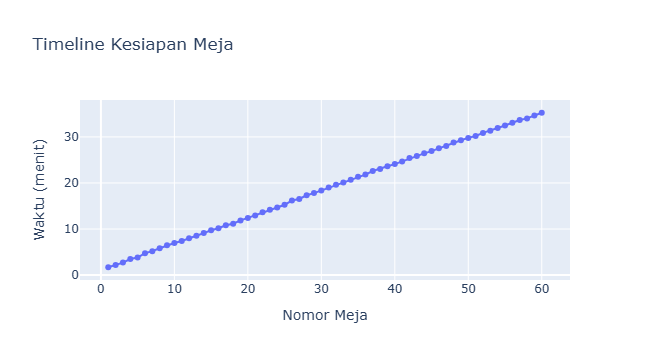

In [7]:
df_meja = pd.DataFrame({
    'meja': range(1, config['total_meja'] + 1),
    'waktu': [max(finish3[i*3:(i+1)*3]) for i in range(config['total_meja'])]
})

fig1 = go.Figure()
fig1.add_trace(go.Scatter(
    x=df_meja['meja'],
    y=df_meja['waktu']/60,
    mode='lines+markers'
))

fig1.update_layout(
    title="Timeline Kesiapan Meja",
    xaxis_title="Nomor Meja",
    yaxis_title="Waktu (menit)"
)

fig1.show()

In [ ]:
fig2 = go.Figure()
fig2.add_trace(go.Histogram(x=batches))

fig2.update_layout(
    title="Distribusi Ukuran Batch (Stage 2)",
    xaxis_title="Ukuran Batch",
    yaxis_title="Frekuensi"
)

fig2.show()